# Run 1-Bit HHL track simulation toy model with 8 particles and 3 layers 
This Jupyter notebook is compatible with Python 3.13, Qiskit v2.1, Qiskit runtime version: 0.40 and Qiskit Runtime V2 primitives.
|||
|-|-|
|**Author:** |Alain Chancé|
|**Date:** |September 29, 2025|
|**Version:** |**1.00**|
|**Credit:**|
This jupyter notebook and the Python file [One_Bit_HHL_Simulation.py](https://github.com/AlainChance/LHCb_VeLo_Toy_Model_1-Bit_HHL/blob/main/One_Bit_HHL_Simulation.py) are derived from the Jupyter notebook [test.ipynb](https://github.com/GeorgeWilliam1999/LHCb_VeLo_Toy_Model/blob/main/test.ipynb) in the repository [LHCb_VeLo_Toy_Model](https://github.com/GeorgeWilliam1999/LHCb_VeLo_Toy_Model/tree/main) owned by George William Scriven, [GeorgeWilliam1999](https://orcid.org/0009-0004-9997-1647). Relevant documentation can be found in the Jupyter notebook [Tracking Toy Model Demo](https://github.com/Xenofon-Chiotopoulos/Tracking_Toy_model/blob/main/example_notebook.ipynb) in the public repository [Tracking_Toy_model](https://github.com/Xenofon-Chiotopoulos/Tracking_Toy_model/tree/main) owned by Xenofon Chiotopoulos.
|**References:**|
[LHCb_VeLo_Toy_Model](https://github.com/GeorgeWilliam1999/LHCb_VeLo_Toy_Model/tree/main)
[test.ipynb](https://github.com/GeorgeWilliam1999/LHCb_VeLo_Toy_Model/blob/main/test.ipynb)
[George_Sandbox.ipynb](https://github.com/GeorgeWilliam1999/LHCb_VeLo_Toy_Model/blob/main/George_Sandbox.ipynb)
[Xenofon Chiotopoulos, TrackHHL: A Quantum Computing Algorithm for Track Reconstruction at the LHCb](https://indico.cern.ch/event/1338689/contributions/6010017/attachments/2951297/5188722/CHEP_ppt.pdf)
[Xenofon Chiotopoulos, Miriam Lucio Martinez, Davide Nicotra, Jacco A. de Vries, Kurt Driessens, Marcel Merk, and Mark H.M. Winands, TrackHHL: A Quantum Computing Algorithm for Track Reconstruction at the LHCb, EPJ Web of Conferences 337, 01181 (2025)](https://doi.org/10.1051/epjconf/202533701181)
[Tracking Toy Model Demo](https://github.com/Xenofon-Chiotopoulos/Tracking_Toy_model/blob/main/example_notebook.ipynb)
[D. Nicotra et al., arXiv:2308.00619v2, 7 Oct 2023, A quantum algorithm for track reconstruction in the LHCb vertex detector](https://arxiv.org/pdf/2308.00619)
[Okawa, Hideki, Quantum Algorithms for Track Reconstruction at High Energy Colliders, Workshop of Tracking in Particle Physics Experiments, May 17-19, 2024](https://indico.ihep.ac.cn/event/21775/contributions/155907/attachments/78247/97329/okawa_QTrack_20240517.pdf)
[Primary Vertex Reconstruction at LHCb, LHCb-PUB-2014-044, October 21, 2014](https://cds.cern.ch/record/1756296/files/LHCb-PUB-2014-044.pdf)
[SQD_Alain](https://github.com/AlainChance/SQD_Alain)

In [1]:
import matplotlib.pyplot as plt

In [2]:
from One_Bit_HHL_Simulation import One_Bit_HHL

Patching HHLAlgorithm with Suzuki-Trotter methods...
Qiskit version: 2.1.0
Qiskit Aer version: 0.17.1
Qiskit runtime version: 0.40.1


## Setup configuration parameters

In [3]:
config = {
    #--------------------
    # Simulation options
    #--------------------
    "dz": 20,                           # layer spacing (mm)
    "layers": 3,                        # Number of layers
    "n_particles": [8],                 # Number of particles
    "p_vertices": [(0,0,10)],           # Primary vertices
    "do_draw": False,                   # Whether to draw the HHL circuit
    "measurement_error": 0.0,           # HIT RESOLUTION (sigma on measurement) (sigma)
    "collision_noise": 0.0,             # MULTIPLE SCATTERING (angular noise proxy)
    "ghost_rate": 1e-2,                 # Ghost (fake) track rate
    "drop_rate": 0.0,                   # Hit drop (inefficiency) rate
    "display_tracks": True,             # Whether to display events and ghost tracks
    "do_spectrum": False,               # Whether to analyze the classical solution spectrum
    "do_print_counts": True,            # Whether to print raw measurement counts
    "resolution": 40,                   # Resolution for plots of tracks - Increase for finer mesh
    #------------------------------------------
    # Files containing token (API key) and CRN
    #------------------------------------------
    "token_file": "Token.txt",          # Token file
    "CRN_file": "CRN.txt",              # CRN file
    #-------------
    # Run options
    #-------------
    "backend_name": "ibm_torino",       # AerSimulator noiseless or Fake QPU or real IBM cloud backend name
    "run_on_QPU": True,                 # Whether to run the quantum circuit on the target hardware
    "nshots": 100000,                   # Number of shots
    'opt_level':1,                      # Optimization level
    "poll_interval": 5,                 # Poll interval in seconds for job monitor
    "timeout": 600,                     # Time out in seconds for gob monitor
}

## Create an instance of the One_Bit_HHL class from the configuration dictionary

In [4]:
try:
    My_HHL = One_Bit_HHL(**config)
except Exception as e:
   print(f"Error creating 1_Bit_HHL instance: {e}")


Simulation options
layer spacing (mm), dz: 20
layers: 3
n_particles: [8]
primary_vertices: [(0, 0, 10)]
do_draw: False
num_time_qubits: 2
measurement hit resolution: 0.0
multiple scattering collision noise: 0.0
ghost (fake) track rate: 0.01
hit drop (inefficiency) rate: 0.0
display_hits: False
display_tracks: True
plot_tracks: True
do_spectrum: False
do_print_counts: True
resolution: 40
gain: 0.3
lam_s: 6
angle_pi: True
Backend name: ibm_torino
Run on QPU: True
Number of shots: 100000
Optimization level: 1
Token read from file:  Token.txt
CRN code read from file:  CRN.txt


## Setup events


Initial particle states

Event particles
Type: MIP, Position: (0, 0, 10), Direction: (-0.045783860305550456, -0.04689277042154046), p/q: 0.4557656363606953
Type: MIP, Position: (0, 0, 10), Direction: (0.018495154736601113, -0.16518765062384663), p/q: 0.4610298965192922
Type: MIP, Position: (0, 0, 10), Direction: (0.06992337245587077, -0.09090632745008238), p/q: 0.4577712095283813
Type: MIP, Position: (0, 0, 10), Direction: (-0.04133189726454561, -0.1655378511367863), p/q: 0.46136223181838265
Type: MIP, Position: (0, 0, 10), Direction: (-0.07063474530068202, -0.12214211529368597), p/q: 0.4592946621991359
Type: MIP, Position: (0, 0, 10), Direction: (-0.16092672812635997, 0.15477855157742743), p/q: 0.465988631443036
Type: MIP, Position: (0, 0, 10), Direction: (-0.13858473795373058, -0.11274523300351644), p/q: 0.4619908094428227
Type: MIP, Position: (0, 0, 10), Direction: (0.09071811979189373, 0.1766142289067715), p/q: 0.46366779804939207

Event tracks

Track ID: 0
  Hit ID: 0, x: -0.4578

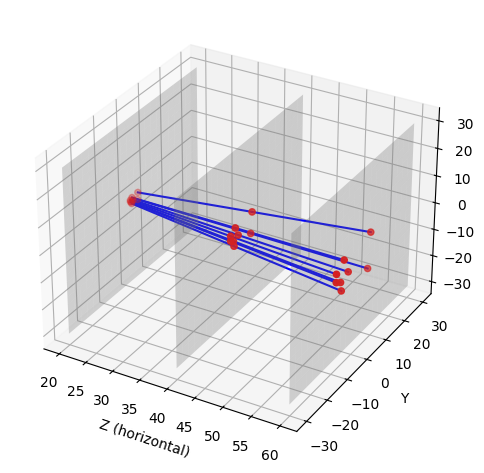


Plotting event tracks with ghost hits (false tracks)


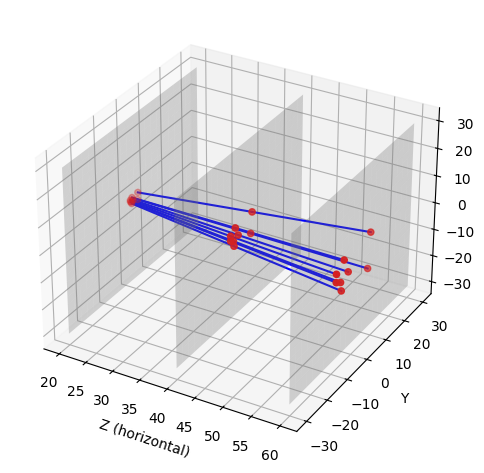

In [5]:
My_HHL.setup_events()

## Setup Hamiltonian

Shape of Hamiltonian matrix A: (128, 128)


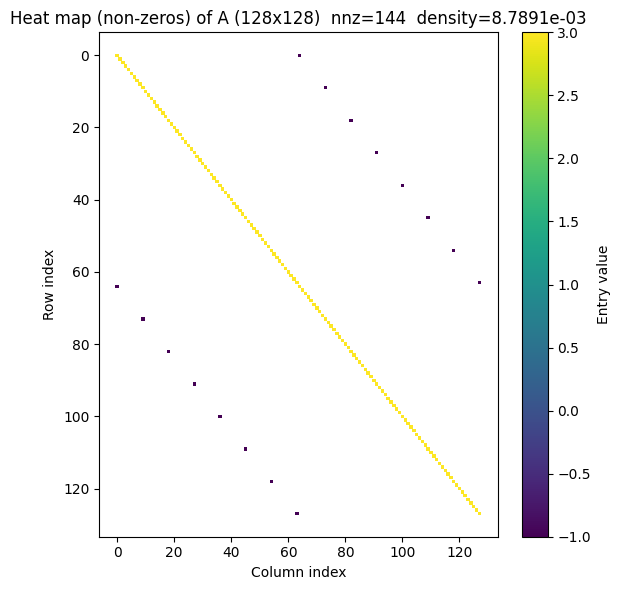

Eigenvalues of Hamiltonian matrix A:
[4. 2. 4. 2. 4. 2. 4. 2. 4. 2. 4. 2. 4. 2. 4. 2. 3. 3. 3. 3. 3. 3. 3. 3.
 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3.
 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3.
 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3.
 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3.
 3. 3. 3. 3. 3. 3. 3. 3.]


In [6]:
My_HHL.setup_Hamiltonian()

## Run classical and 1-Bit HHL simulations


-----------------------------------------------------------------------------------
 Solving classically with only the first three layers using scipy.sparse.linalg.cg
-----------------------------------------------------------------------------------

Classical solution:
[0.5        0.33333333 0.33333333 0.33333333 0.33333333 0.33333333
 0.33333333 0.33333333 0.33333333 0.5        0.33333333 0.33333333
 0.33333333 0.33333333 0.33333333 0.33333333 0.33333333 0.33333333
 0.5        0.33333333 0.33333333 0.33333333 0.33333333 0.33333333
 0.33333333 0.33333333 0.33333333 0.5        0.33333333 0.33333333
 0.33333333 0.33333333 0.33333333 0.33333333 0.33333333 0.33333333
 0.5        0.33333333 0.33333333 0.33333333 0.33333333 0.33333333
 0.33333333 0.33333333 0.33333333 0.5        0.33333333 0.33333333
 0.33333333 0.33333333 0.33333333 0.33333333 0.33333333 0.33333333
 0.5        0.33333333 0.33333333 0.33333333 0.33333333 0.33333333
 0.33333333 0.33333333 0.33333333 0.5        0.5        0

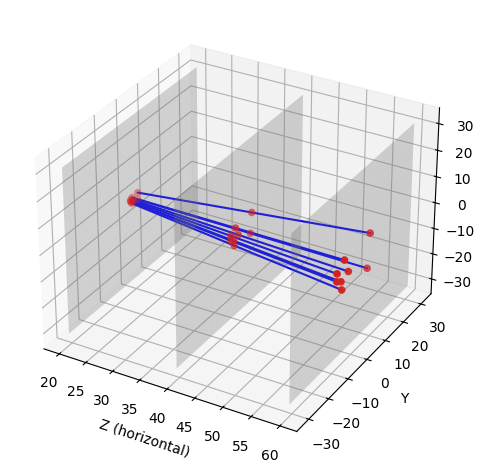


                  EVENT VALIDATION METRICS                  
Total Reconstructed Tracks:                              8
Total Truth Tracks:                                      8
Reconstruction Efficiency:                         100.00%
Ghost Rate:                                          0.00%
Clone Fraction:                           0.00% (0 clones)
Hit Efficiency:                                    100.00%
Purity:                                            100.00%


-------------------------------------------------------
 1-Bit HHL simulation with only the first three layers
-------------------------------------------------------

Number of qubits in HHL circuit:  10
backend_name: ibm_torino
Backend name: ibm_torino
Version: 2
Number of qubits: 133
Gate counts (w/ pre-init passes): OrderedDict({'sx': 9556, 'rz': 7099, 'cz': 5138, 'measure': 8})

The depth of the isa quantum circuit is: 31019
Gate statistics for the circuit:
OrderedDict({'h': 19832, 'sdg': 19112, 'p': 7099, 'cx': 

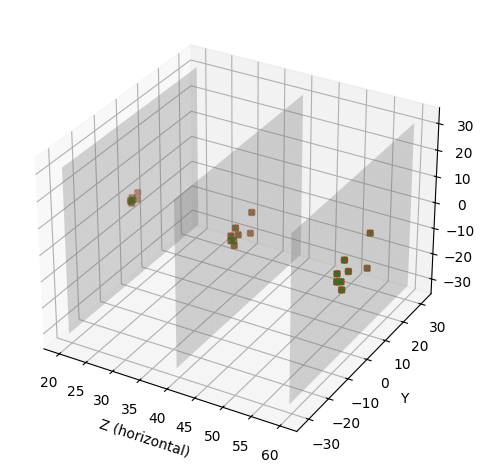

In [7]:
My_HHL.run_simulation()

## References
### The Large Hadron Collider beauty (LHCb) experiment at CERN
- [The Large Hadron Collider beauty (LHCb) experiment](https://home.cern/science/experiments/lhcb)
- [LHCb Taking a closer look at LHC](https://www.lhc-closer.es/taking_a_closer_look_at_lhc/0.lhcb)
- [LHCb @ Syracuse: An overview](https://hep.syr.edu/quark-flavor-physics/lhcb-cern/)
- [LHCb Upgrade II, Detector and Physics Prospects, Vincenzo Vagnoni (INFN Bologna, CERN), for the LHCb collaboration, The 2024 International Workshop on Future Tau Charm Facilities, 15 January 2024](https://indico.pnp.ustc.edu.cn/event/91/contributions/6351/attachments/1859/3063/FTCF%2015%20January%202024.pdf)
### LHCb Velo Toy Model
- [LHCb_VeLo_Toy_Model](https://github.com/GeorgeWilliam1999/LHCb_VeLo_Toy_Model/tree/main)
- [test.ipynb](https://github.com/GeorgeWilliam1999/LHCb_VeLo_Toy_Model/blob/main/test.ipynb)
- [George_Sandbox.ipynb](https://github.com/GeorgeWilliam1999/LHCb_VeLo_Toy_Model/blob/main/George_Sandbox.ipynb)
- [Xenofon Chiotopoulos, TrackHHL: A Quantum Computing Algorithm for Track Reconstruction at the LHCb](https://indico.cern.ch/event/1338689/contributions/6010017/attachments/2951297/5188722/CHEP_ppt.pdf)
- [Tracking Toy Model Demo](https://github.com/Xenofon-Chiotopoulos/Tracking_Toy_model/blob/main/example_notebook.ipynb)
### Algorithms for Track Reconstruction
- [Xenofon Chiotopoulos, TrackHHL: A Quantum Computing Algorithm for Track Reconstruction at the LHCb](https://indico.cern.ch/event/1338689/contributions/6010017/attachments/2951297/5188722/CHEP_ppt.pdf)
- [Xenofon Chiotopoulos, Miriam Lucio Martinez, Davide Nicotra, Jacco A. de Vries, Kurt Driessens, Marcel Merk, and Mark H.M. Winands, TrackHHL: A Quantum Computing Algorithm for Track Reconstruction at the LHCb, EPJ Web of Conferences 337, 01181 (2025)](https://doi.org/10.1051/epjconf/202533701181)
- [Okawa, Hideki, Quantum Algorithms for Track Reconstruction at High Energy Colliders, Workshop of Tracking in Particle Physics Experiments, May 17-19, 2024](https://indico.ihep.ac.cn/event/21775/contributions/155907/attachments/78247/97329/okawa_QTrack_20240517.pdf)
- [Quantum pathways for charged track finding in high-energy collisions, Front. Artif. Intell., 30 May 2024, Sec. Big Data and AI in High Energy Physics, Volume 7 - 2024](https://www.frontiersin.org/journals/artificial-intelligence/articles/10.3389/frai.2024.1339785/full)
- [D. Nicotra et al., arXiv:2308.00619v2, 7 Oct 2023, A quantum algorithm for track reconstruction in the LHCb vertex detector](https://arxiv.org/pdf/2308.00619)
- [Primary Vertex Reconstruction at LHCb, LHCb-PUB-2014-044, October 21, 2014](https://cds.cern.ch/record/1756296/files/LHCb-PUB-2014-044.pdf)
### Quantum Phase Estimation (QPE) Algorithm
- [Stefano Scali, Josh Kirsopp, Antonio Márquez Romero, Michał Krompiec, Spectral subspace extraction via incoherent quantum phase estimation, 16 Oct 2025, arXiv:2510.14744 quant-ph](
https://doi.org/10.48550/arXiv.2510.14744)
- [Antoine Lemelin, Christophe Pere, Olivier Landon-Cardinal, Camille Coti, Mid-circuit measurement as an algorithmic primitive, 2 Sep 2025, arXiv:2506.00118 quant-ph](
https://doi.org/10.48550/arXiv.2506.00118) 
- [Phase estimation variants and its implication for quantum/classical architecture by Microsoft, From the need to hybridize algorithmically to the need to integrate QPUs with CPUs, J. Mikael, EDF, E. Vergnaud, Teratec TQCI, Conference on QPU/CPU Integration](https://www.teratec.eu/library/seminaires/2022/TQCI/Microsoft_Hybrid_QC_EDF.pdf)
- [quantum-phase-estimation.ipynb, Qiskit Textbook](https://github.com/Qiskit/textbook/blob/main/notebooks/ch-algorithms/quantum-phase-estimation.ipynb)
- [qiskit.circuit.library.phase_estimation](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.phase_estimation)
- [Non-variational and Phase Estimation algorithms, Quantinuum's InQuanto 5.1.0](https://docs.quantinuum.com/inquanto/manual/algorithms/non_variational_overview.html)
### Simulated Bifurcation Algorithm
- [Simulated Bifurcation for Python](https://github.com/bqth29/simulated-bifurcation-algorithm/tree/main)
- [Hideki Okawa, Qing-Guo Zeng, Xian-Zhe Tao, Man-Hong Yung, Quantum-Annealing-Inspired Algorithms for Track Reconstruction at High-Energy Colliders, 30 Aug 2024, 	arXiv:2402.14718 quant-ph](https://doi.org/10.48550/arXiv.2402.14718)
### Quantum Machine Learning in High Energy Physics
- [Wen Guan et al, Quantum machine learning in high energy physics, 2021 Mach. Learn.: Sci. Technol. 2 011003](https://quantum.web.cern.ch/sites/default/files/2021-07/Quantum%20Machine%20Learning%20in%20High%20Energy%20Physics.pdf)
- [Gray HM. Quantum pattern recognition algorithms for charged particle tracking. Philos Trans A Math Phys Eng Sci. 2022 Feb 7;380(2216):20210103. doi: 10.1098/rsta.2021.0103. Epub 2021 Dec 20. PMID: 34923843; PMCID: PMC8685607.](https://pmc.ncbi.nlm.nih.gov/articles/PMC8685607/)
### Hough transform
- [Straight line Hough transform](https://scikit-image.org/docs/stable/auto_examples/edges/plot_line_hough_transform.html)
- [Frank Klefenz, Nico Wittrock, Frank Feldhoff, Parallel Quantum Hough Transform, 15 Nov 2023, arXiv:2311.09002 eess.IV](https://doi.org/10.48550/arXiv.2311.09002)
- [F. Klefenz, K.-H. Noffz, W. Conen, R. Zoz, A. Kugel, and R. Manner. “Track recognition in 4 µs by a systolic trigger processor using a parallel Hough transform”. IEEE Transactions on Nuclear Science 40, 688–691 (1993)](https://ieeexplore.ieee.org/document/256642)
### SQD_Alain
- [SQD_Alain](https://github.com/AlainChance/SQD_Alain)